In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def load_results(file_path):
    """
    Load results from a pickle file.

    Args:
        file_path (str): Path to the pickle file.

    Returns:
        dict: Dictionary containing the loaded results.
    """
    try:
        with open(file_path, 'rb') as f:
            results = pickle.load(f)
        return results
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None 

In [9]:
rel_path = "/home/khain/FSNet/"
dir_path = "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20251106-120534_MLP_FSNet_seed0_dropout0.1_finetune_20251106-114103_model_20/results.pkl"

results = load_results(rel_path + dir_path)

In [10]:
print(results['training_time_seconds'])
print("\n")
print(results['config'])

807.4603755474091


{'seed': 0, 'train_size': -1, 'test_size': 2000, 'val_size': 1000, 'batch_size': 512, 'test_batch_size': [256, 512], 'lr': 0.0001, 'lr_decay': 0.9, 'lr_decay_step': 100, 'num_epochs': 300, 'eval_step': 20, 'hidden_dim': 1024, 'num_layers': 4, 'dropout': 0.1, 'penalty': {'obj_weight': 1.0, 'eq_pen_weight': 50.0, 'ineq_pen_weight': 50.0}, 'adaptive_penalty': {'obj_weight': 1.0, 'eq_pen_weight_max': 500.0, 'ineq_pen_weight_max': 100.0, 'eq_pen_weight': 30.0, 'ineq_pen_weight': 30.0, 'increasing_rate': 2.0}, 'FSNet': {'obj_weight': 1.0, 'dist_weight': 5.0, 'eq_pen_weight': 10.0, 'ineq_pen_weight': 10.0, 'val_tol': 1e-09, 'test_val_tol': 1e-09, 'decay_tol_step': 100, 'memory_size': 30, 'max_iter': 50, 'max_diff_iter': 30, 'scale': 1000}, 'DC3': {'obj_weight': 1.0, 'eq_pen_weight': 1.0, 'ineq_pen_weight': 100.0, 'corr_lr': 1e-06, 'max_corr_steps': 20, 'corr_momentum': 0.5}, 'projection': {'obj_weight': 1.0, 'dist_weight': 3.0}, 'S3Net': {'obj_weight': 1.0, 'dist_weight': 

In [4]:
def get_train_metrics(results):
    """
    Extract training metrics from the results dictionary.

    Args:
        results (dict): Dictionary containing training history.

    Returns:
        dict: Dictionary containing lists of training metrics.
    """
    train_metrics = {
        'obj': [],
        'loss': [],
        'eq_violation': [],
        'ineq_violation': [],
        'eq_violation_l1': [],
        'ineq_violation_l1': [],
        'distance': []    
    }

    for k in range(len(results['train_history'])):
        for key in train_metrics.keys():
            train_metrics[key].append(results['train_history'][k][key])
    
    return train_metrics

def get_val_metrics(results):
    """
    Extract validation metrics from the results dictionary.

    Args:
            results (dict): Dictionary containing validation history.

    Returns:
            dict: Dictionary containing lists of validation metrics.
    """
    val_metrics = {
            'objective': [],
            'true_objective': [],
            'opt_gap_mean': [],
            'opt_gap_std': [],
            'opt_gap_max': [],
            'opt_gap_min': [],
            'eq_violation_l2_mean': [],
            'eq_violation_l2_max': [],
            'ineq_violation_l2_mean': [],
            'ineq_violation_l2_max': [],
            'eq_violation_l1_mean': [],
            'eq_violation_l1_max': [],
            'ineq_violation_l1_mean': [],
            'ineq_violation_l1_max': [],
            'eq_violation_max_mean': [],
            'eq_violation_max_max': [],
            'ineq_violation_max_mean': [],
            'ineq_violation_max_max': [],
            'solution_distance_mean': [],
            'solution_distance_std': [],
            'solution_distance_max': []
    }

    for k in range(len(results['val_history'])):
        for key in val_metrics.keys():
            val_metrics[key].append(results['val_history'][k][key])

    return val_metrics

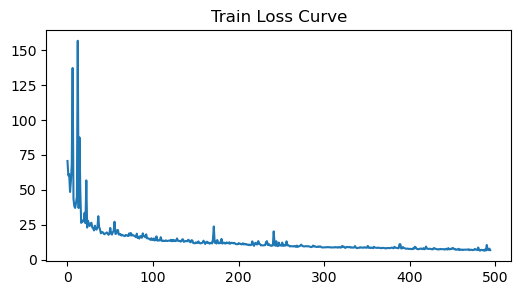

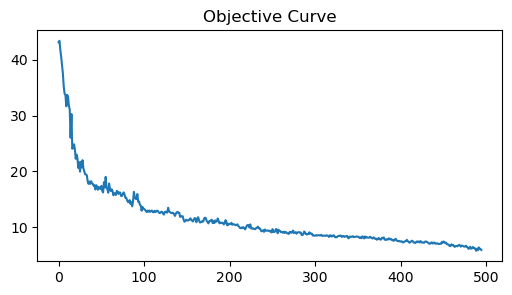

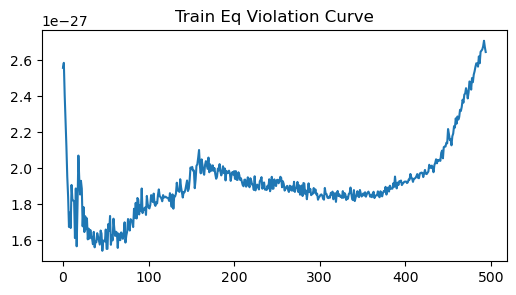

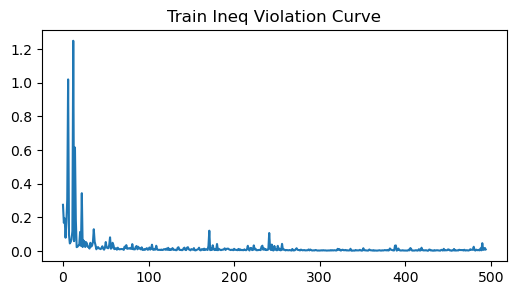

In [5]:
train_metrics = get_train_metrics(results)

start = 5
end = 1000

plt.figure(figsize=(6, 3))
plt.title('Train Loss Curve')
plt.plot(train_metrics['loss'][start:end], label='Train Loss')

plt.figure(figsize=(6, 3))
plt.title('Objective Curve')
plt.plot(train_metrics['obj'][start:end], label='Train Loss')

plt.figure(figsize=(6, 3))
plt.title('Train Eq Violation Curve')
plt.plot(train_metrics['eq_violation'][start:end], label='Train Eq Violation')

plt.figure(figsize=(6, 3))
plt.title('Train Ineq Violation Curve')
plt.plot(train_metrics['ineq_violation'][start:end], label='Train Ineq Violation')

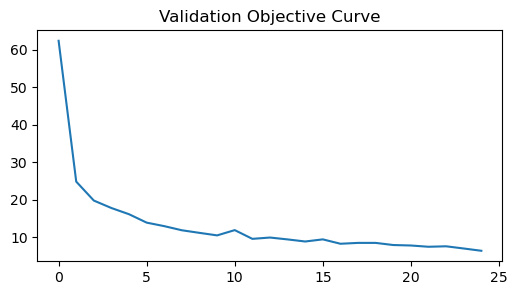

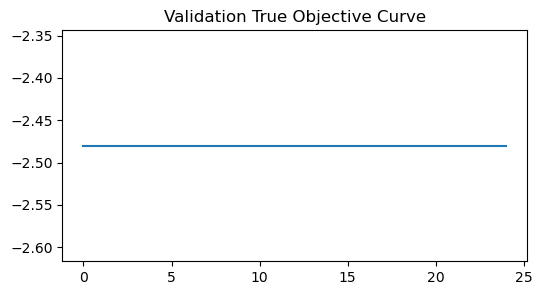

In [6]:
val_metrics = get_val_metrics(results)

plt.figure(figsize=(6, 3))
plt.title('Validation Objective Curve')
plt.plot(val_metrics['objective'], label='Val Objective')

plt.figure(figsize=(6, 3))
plt.title('Validation True Objective Curve')
plt.plot(val_metrics['true_objective'], label='Val True Objective')


In [7]:
def get_train_metrics_stats(dir_path_seeds):
    num_seeds = len(dir_path_seeds)
    results = [load_results(rel_path + path) for path in dir_path_seeds]
    num_epoch = min([len(res['train_history']) for res in results])
    all_metrics = {
        key: np.zeros((num_seeds, num_epoch))
        for key in [
            'obj', 'loss',
            'eq_violation', 'ineq_violation',
            'eq_violation_l1', 'ineq_violation_l1',
            'distance'
        ]
    }
    for seed_idx, path in enumerate(dir_path_seeds):
        results = load_results(rel_path + path)
        train_metrics = get_train_metrics(results)
        for key in all_metrics.keys():
            all_metrics[key][seed_idx, :] = train_metrics[key][:num_epoch]

    mean_metrics = {key: np.mean(all_metrics[key], axis=0) for key in all_metrics.keys()}
    std_metrics = {key: np.std(all_metrics[key], axis=0) for key in all_metrics.keys()}
    return mean_metrics, std_metrics

def get_val_metrics_stats(dir_path_seeds):
    num_seeds = len(dir_path_seeds)
    results = [load_results(rel_path + path) for path in dir_path_seeds]
    num_evals = min([len(res['val_history']) for res in results])
    all_metrics = {
        key: np.zeros((num_seeds, num_evals))
        for key in [
            'objective', 'true_objective',
            'opt_gap_mean', 'opt_gap_std', 'opt_gap_max', 'opt_gap_min',
            'eq_violation_l2_mean', 'eq_violation_l2_max',
            'ineq_violation_l2_mean', 'ineq_violation_l2_max',
            'eq_violation_l1_mean', 'eq_violation_l1_max',
            'ineq_violation_l1_mean', 'ineq_violation_l1_max',
            'eq_violation_max_mean', 'eq_violation_max_max',
            'ineq_violation_max_mean', 'ineq_violation_max_max',
            'solution_distance_mean', 'solution_distance_std', 'solution_distance_max'
        ]
    }
    for seed_idx, path in enumerate(dir_path_seeds):
        results = load_results(rel_path + path)
        val_metrics = get_val_metrics(results)
        for key in all_metrics.keys():
            all_metrics[key][seed_idx, :] = val_metrics[key][:num_evals]

    mean_metrics = {key: np.mean(all_metrics[key], axis=0) for key in all_metrics.keys()}
    std_metrics = {key: np.std(all_metrics[key], axis=0) for key in all_metrics.keys()}
    return mean_metrics, std_metrics
    

In [8]:
mean_metrics, std_metrics = get_val_metrics_stats(dir_path_seeds)
start_eval = 1
end_eval = 40
eval_range = range(start_eval, end_eval)
# mutiplie eval_range by eval_step
eval_step = 20
eval_range = [x * eval_step for x in eval_range]
for key in mean_metrics.keys():
    plt.figure()
    plt.title(f'Validation {key} Curve')
    plt.plot(eval_range, mean_metrics[key][start_eval:end_eval], label=f'Mean {key}')
    plt.fill_between(eval_range,
                     mean_metrics[key][start_eval:end_eval] - std_metrics[key][start_eval:end_eval],
                     mean_metrics[key][start_eval:end_eval] + std_metrics[key][start_eval:end_eval],
                     alpha=0.3, label=f'Std Dev {key}')
    plt.xlabel('Evaluation')
    plt.ylabel(key)
    plt.legend()
    plt.show()

NameError: name 'dir_path_seeds' is not defined

In [11]:
rel_path = "/home/khain/FSNet/"
dir_path = "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20251106-163705_MLP_penalty_seed3_dropout0.1_finetune_20251031-073026_model_20/results.pkl"
# 20251105-161915_MLP_penalty_seed0_dropout0.1
# 20251105-154420_MLP_DC3_seed0_dropout0.1
results = load_results(rel_path + dir_path)

# Get batch comparison data from the loaded results
batch_comparison = results['test_results']['batch_size_comparison']

# Create a more readable DataFrame by expanding the metrics
readable_data = []
for batch_size, data in batch_comparison.items():
    metrics = data['metrics']
    row = {
        'Batch Size': batch_size,
        'Opt Gap Mean': f"{metrics['opt_gap_mean']:.4f}",
        'Opt Gap Std': f"{metrics['opt_gap_std']:.4f}",
        'Opt Gap Max': f"{metrics['opt_gap_max']:.4f}",
        'Eq Violation Mean': f"{metrics['eq_violation_l1_mean']:.2e}",
        'Eq Violation Max': f"{metrics['eq_violation_l1_max']:.2e}",
        'Ineq Violation Mean': f"{metrics['ineq_violation_l1_mean']:.2e}",
        'Ineq Violation Max': f"{metrics['ineq_violation_l1_max']:.2e}",
        'Average Batch Time (s)': f"{metrics['avg_inference_time']:.4f}",
    }
    readable_data.append(row)

df_readable = pd.DataFrame(readable_data)
df_readable_styled = df_readable.style.set_properties(**{'text-align': 'center'})
display(df_readable_styled)

,Batch Size,Opt Gap Mean,Opt Gap Std,Opt Gap Max,Eq Violation Mean,Eq Violation Max,Ineq Violation Mean,Ineq Violation Max,Average Batch Time (s)
0,256,-2.3001,1.1457,2.9377,3.23e-01,5.42e-01,3.10e-02,6.50e-01,0.0002
1,512,-2.3417,0.6926,4.5516,3.23e-01,5.85e-01,3.11e-02,7.45e-01,0.0002


In [ ]:
# LOOKING FOR FOLDERS

# filter all folder name in rel_path = "/home/khain/FSNet/results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000" that contain "finetune_20251030-232939_model_20"
import os
rel_path = "/home/khain/FSNet/results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000"
dir_path_seeds = []
for folder_name in os.listdir(rel_path):
    if "finetune_20251030-232939_model_200" in folder_name:
        dir_path_seeds.append(os.path.join(folder_name))

# print line by line dir_path_seeds
for path in dir_path_seeds:
    print(f"\"{path}\",")

In [ ]:
# multiple seeds
rel_path = "/home/khain/FSNet/results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000"
dir_path_seeds = np.array([
    [
        "20251030-234500_MLP_FSNet_seed0_dropout0.1_finetune_20251030-232939_model_20",
        "20251031-005543_MLP_FSNet_seed1_dropout0.1_finetune_20251030-232939_model_20",
        "20251031-011200_MLP_FSNet_seed2_dropout0.1_finetune_20251030-232939_model_20",
        "20251031-012540_MLP_FSNet_seed3_dropout0.1_finetune_20251030-232939_model_20"
    ],
    [
        "20251030-235837_MLP_FSNet_seed0_dropout0.1_finetune_20251030-232939_model_60",
        "20251031-014302_MLP_FSNet_seed1_dropout0.1_finetune_20251030-232939_model_60",
        "20251031-015852_MLP_FSNet_seed2_dropout0.1_finetune_20251030-232939_model_60",
        "20251031-021430_MLP_FSNet_seed3_dropout0.1_finetune_20251030-232939_model_60",
    ],
    [
        "20251031-001414_MLP_FSNet_seed0_dropout0.1_finetune_20251030-232939_model_100",
        "20251031-022921_MLP_FSNet_seed1_dropout0.1_finetune_20251030-232939_model_100",
        "20251031-024552_MLP_FSNet_seed2_dropout0.1_finetune_20251030-232939_model_100",
        "20251031-030129_MLP_FSNet_seed3_dropout0.1_finetune_20251030-232939_model_100",
    ],
    [
        "20251031-003458_MLP_FSNet_seed0_dropout0.1_finetune_20251030-232939_model_200",
        "20251031-031716_MLP_FSNet_seed1_dropout0.1_finetune_20251030-232939_model_200",
        "20251031-033222_MLP_FSNet_seed2_dropout0.1_finetune_20251030-232939_model_200",
        "20251031-034823_MLP_FSNet_seed3_dropout0.1_finetune_20251030-232939_model_200",
    ]
])

obj_gap_mean_all = np.zeros_like(dir_path_seeds, dtype=float)
obj_gap_std_all = np.zeros_like(dir_path_seeds, dtype=float)
obj_gap_max_all = np.zeros_like(dir_path_seeds, dtype=float)
eq_viol_l1_mean_all = np.zeros_like(dir_path_seeds, dtype=float)
eq_viol_l1_max_all = np.zeros_like(dir_path_seeds, dtype=float)
ineq_viol_l1_mean_all = np.zeros_like(dir_path_seeds, dtype=float)
ineq_viol_l1_max_all = np.zeros_like(dir_path_seeds, dtype=float)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==== Data ====
seeds = [0, 1, 2, 3]

dc3_data = {
    'opt_gap': [9.8420, 28.6005, 8.3288, -2.5207],
    'eq_viol': [3.28e-13, 2.72e-13, 3.55e-13, 2.58e-13],
    'ineq_viol': [5.89e-02, 4.42e-01, 2.95e-01, 7.41e-02],
}

sup_20_dc3_data = {
    'opt_gap': [1, 1, 1, 1],
    'eq_viol': [1, 1, 1, 1],
    'ineq_viol': [1, 1, 1, 1],
}

sup_100_dc3_data = {
    'opt_gap': [1, 1, 1, 1],
    'eq_viol': [1, 1, 1, 1],
    'ineq_viol': [1, 1, 1, 1],
}

# Combine in long format
df = pd.concat([
    pd.DataFrame(dc3_data).assign(method="DC3"),
    pd.DataFrame(sup_20_dc3_data).assign(method="Sup-20-DC3"),
    pd.DataFrame(sup_100_dc3_data).assign(method="Sup-100-DC3"),
    # pd.DataFrame(sup_100_dc3_data).assign(method="Sup-40-DC3"),
], ignore_index=True)

df = df.melt(id_vars="method", var_name="metric", value_name="value")

# ==== Colors and labels ====
palette = {
    "DC3": "#E24A33",          # soft red
    "Sup-20-DC3": "#1F3C25", # medium green
    "Sup-100-DC3": "#468855", # warm orange
}
metric_titles = {
    "opt_gap": "Optimality Gap (%)",
    "eq_viol": "Equality Violation",
    "ineq_viol": "Inequality Violation"
}

# ==== Plot ====
sns.set(style="whitegrid", font_scale=1.0)
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for i, metric in enumerate(["opt_gap", "eq_viol", "ineq_viol"]):
    ax = axes[i]
    sns.boxplot(
        data=df[df["metric"] == metric],
        x="method", y="value",
        palette=palette,
        ax=ax, width=0.6, fliersize=3,
        boxprops=dict(alpha=0.8, linewidth=1),
        medianprops=dict(color="black", linewidth=1.2)
    )
    ax.set_title(metric_titles[metric])
    ax.set_xlabel("")
    ax.set_ylabel("Value" if i == 0 else "")
    ax.tick_params(axis='x', rotation=20)
    ax.grid(True, linestyle="--", alpha=0.5)

    if metric == "opt_gap":
        ax.set_yscale("symlog")

    plt.tight_layout()
plt.show()


In [ ]:
# SUBOPT 0
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==== Data ====
seeds = [0, 1, 2, 3]

fsnet_data = {
    'opt_gap': [0.1878, -5.8723, 12.6649, -0.0671],
    'eq_viol': [1.06e-04, 8.90e-05, 1.04e-04, 8.40e-05],
    'ineq_viol': [4.97e-07, 6.04e-07, 3.95e-07, 5.22e-07],
}

sup_20_fsnet_data = {
    'opt_gap': [-4.7116, -4.0072, -3.6939, -2.1990],
    'eq_viol': [9.26e-5, 4.43e-5, 8.68e-5, 2.56e-5],
    'ineq_viol': [4.81e-7, 5.14e-7, 5.12e-7, 7.05e-7],
}

sup_60_fsnet_data = {
    'opt_gap': [-4.7383, -3.6836, -3.1120, -2.7957],
    'eq_viol': [9.50e-5, 3.99e-5, 2.10e-5, 5.43e-5],
    'ineq_viol': [5.29e-7, 4.4693e-7, 1.95e-7, 4.75e-7],
}

sup_100_fsnet_data = {
    'opt_gap': [2.9452e1, -5.5353, -3.1006, -2.2784],
    'eq_viol': [1.05e1, 8.17e-5, 6.43e-5, 3.45e-5],
    'ineq_viol': [3.4949, 4.89e-7, 5.60e-7, 3.92e-7],
}

sup_200_fsnet_data = {
    'opt_gap': [-3.2018, 7.9433, -2.8917, -2.1027],
    'eq_viol': [4.00e-5, 5.95e-3, 5.18e-5, 3.92e-5],
    'ineq_viol': [2.44e-7, 1.18e-3, 5.84e-7, 2.57e-7],
}

# Combine in long format
df = pd.concat([
    pd.DataFrame(fsnet_data).assign(method="FSNet"),
    pd.DataFrame(sup_20_fsnet_data).assign(method="Sup-20-FSNet"),
    pd.DataFrame(sup_60_fsnet_data).assign(method="Sup-60-FSNet"),
    pd.DataFrame(sup_100_fsnet_data).assign(method="Sup-100-FSNet"),
    pd.DataFrame(sup_200_fsnet_data).assign(method="Sup-200-FSNet")
], ignore_index=True)

df = df.melt(id_vars="method", var_name="metric", value_name="value")

# ==== Colors and labels ====
palette = {
    "FSNet": "#E24A33",          # soft red
    "Sup-20-FSNet": "#1F3C25", # medium green
    "Sup-60-FSNet": "#468855", # warm orange
    "Sup-100-FSNet": "#68C67E", # warm orange
    "Sup-200-FSNet": "#74E38E", # medium green
}
metric_titles = {
    "opt_gap": "Optimality Gap (%)",
    "eq_viol": "Equality Violation",
    "ineq_viol": "Inequality Violation"
}

# ==== Plot ====
sns.set(style="whitegrid", font_scale=1.0)
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for i, metric in enumerate(["opt_gap", "eq_viol", "ineq_viol"]):
    ax = axes[i]
    sns.boxplot(
        data=df[df["metric"] == metric],
        x="method", y="value",
        palette=palette,
        ax=ax, width=0.6, fliersize=3,
        boxprops=dict(alpha=0.8, linewidth=1),
        medianprops=dict(color="black", linewidth=1.2)
    )
    ax.set_title(metric_titles[metric])
    ax.set_xlabel("")
    ax.set_ylabel("Value" if i == 0 else "")
    ax.tick_params(axis='x', rotation=20)
    ax.grid(True, linestyle="--", alpha=0.5)

    if metric == "opt_gap":
        ax.set_yscale("symlog")

    plt.tight_layout()
plt.show()


In [ ]:
# SUBOPT 0.5
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==== Data ====
seeds = [0, 1, 2, 3]

fsnet_data = {
    'opt_gap': [0.1878, -5.8723, 12.6649, -0.0671],
    'eq_viol': [1.06e-04, 8.90e-05, 1.04e-04, 8.40e-05],
    'ineq_viol': [4.97e-07, 6.04e-07, 3.95e-07, 5.22e-07],
}

sup_20_fsnet_data = {
    'opt_gap': [-3.8159, -5.7887, -3.7948, -2.4095],
    'eq_viol': [3.26e-5, 4.56e-5, 1.07e-4, 2.93e-5],
    'ineq_viol': [2.41e-7, 3.22e-7, 5.31e-7, 8.28e-7],
}

sup_60_fsnet_data = {
    'opt_gap': [-4.6615, -5.3771, -3.7595, -3.3460],
    'eq_viol': [9.48e-5, 8.38e-5, 5.93e-5, 9.31e-5],
    'ineq_viol': [6.17e-7, 3.08e-7, 4.32e-7, 4.56e-7],
}

sup_100_fsnet_data = {
    'opt_gap': [-4.7344, -5.3664, -3.4190, -3.1500],
    'eq_viol': [5.07e-5, 8.17e-5, 7.12e-5, 8.30e-5],
    'ineq_viol': [5.13e-7, 4.59e-7, 4.69e-7, 4.574e-7],
}

sup_200_fsnet_data = {
    'opt_gap': [-4.3393, -3.2787, -3.5439, -2.9968],
    'eq_viol': [9.03e-5, 5.41e-5, 9.38e-5, 5.29e-5],
    'ineq_viol': [4.22e-7, 4.32e-7, 3.28e-7, 4.74e-7],
}

# Combine in long format
df = pd.concat([
    pd.DataFrame(fsnet_data).assign(method="FSNet"),
    pd.DataFrame(sup_20_fsnet_data).assign(method="Sup-20-FSNet"),
    pd.DataFrame(sup_60_fsnet_data).assign(method="Sup-60-FSNet"),
    pd.DataFrame(sup_100_fsnet_data).assign(method="Sup-100-FSNet"),
    pd.DataFrame(sup_200_fsnet_data).assign(method="Sup-200-FSNet")
], ignore_index=True)

df = df.melt(id_vars="method", var_name="metric", value_name="value")

# ==== Colors and labels ====
palette = {
    "FSNet": "#E24A33",          # soft red
    "Sup-20-FSNet": "#1F3C25", # medium green
    "Sup-60-FSNet": "#468855", # warm orange
    "Sup-100-FSNet": "#68C67E", # warm orange
    "Sup-200-FSNet": "#74E38E", # medium green
}
metric_titles = {
    "opt_gap": "Optimality Gap (%)",
    "eq_viol": "Equality Violation",
    "ineq_viol": "Inequality Violation"
}

# ==== Plot ====
sns.set(style="whitegrid", font_scale=1.0)
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for i, metric in enumerate(["opt_gap", "eq_viol", "ineq_viol"]):
    ax = axes[i]
    sns.boxplot(
        data=df[df["metric"] == metric],
        x="method", y="value",
        palette=palette,
        ax=ax, width=0.6, fliersize=3,
        boxprops=dict(alpha=0.8, linewidth=1),
        medianprops=dict(color="black", linewidth=1.2)
    )
    ax.set_title(metric_titles[metric])
    ax.set_xlabel("")
    ax.set_ylabel("Value" if i == 0 else "")
    ax.tick_params(axis='x', rotation=20)
    ax.grid(True, linestyle="--", alpha=0.5)

    if metric == "opt_gap":
        ax.set_yscale("symlog")

    plt.tight_layout()
plt.show()


In [ ]:
# SUBOPT 0.0, SWEEPING DATASIZE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==== Data ====
seeds = [0, 1, 2, 3]

sup_200_fsnet_data = {
    'opt_gap': [-4.7042, -5.7838, -3.6994, -3.3510],
    'eq_viol': [1.12e-4, 8.42e-5, 8.53e-5, 8.55e-5],
    'ineq_viol': [5.59e-7, 5.26e-7, 5.75e-7, 6.52e-7],
}

sup_500_fsnet_data = {
    'opt_gap': [-4.7802, -5.8469, -3.2184, -2.6015],
    'eq_viol': [9.33e-5, 9.66e-5, 8.76e-5, 6.61e-5],
    'ineq_viol': [3.81e-7, 5.57e-7, 3.28e-7, 3.93e-7],
}

sup_1000_fsnet_data = {
    'opt_gap': [-4.7637, -4.4713, -3.7819, -3.3479],
    'eq_viol': [1.04e-4, 7.52e-5, 1.09e-4, 1.04e-4],
    'ineq_viol': [4.25e-7, 5.47e-7, 5.06e-7, 7.14e-7],
}

sup_4000_fsnet_data = {
    'opt_gap': [-3.6051, -4.3475, -2.5842, -3.3340],
    'eq_viol': [2.98e-5, 2.74e-5, 1.89e-5, 9.05e-5],
    'ineq_viol': [1.00e-6, 3.10e-7, 2.80e-7, 6.30e-7],
}

sup_7000_fsnet_data = {
    'opt_gap': [-4.7116, -4.0072, -3.6939, -2.1990],
    'eq_viol': [9.26e-5, 4.43e-5, 8.68e-5, 2.56e-5],
    'ineq_viol': [4.81e-7, 5.14e-7, 5.12e-7, 7.05e-7],
}

# Combine in long format
df = pd.concat([
    pd.DataFrame(sup_200_fsnet_data).assign(method="200-FSNet"),
    pd.DataFrame(sup_500_fsnet_data).assign(method="500-FSNet"),
    pd.DataFrame(sup_1000_fsnet_data).assign(method="1000-FSNet"),
    pd.DataFrame(sup_4000_fsnet_data).assign(method="4000-FSNet"),
    pd.DataFrame(sup_7000_fsnet_data).assign(method="7000-FSNet")
], ignore_index=True)

df = df.melt(id_vars="method", var_name="metric", value_name="value")

# ==== Colors and labels ====
palette = {
    "200-FSNet": "#18261F",          # soft red
    "500-FSNet": "#1F3C25", # medium green
    "1000-FSNet": "#468855", # warm orange
    "4000-FSNet": "#68C67E", # warm orange
    "7000-FSNet": "#74E38E", # medium green
}
metric_titles = {
    "opt_gap": "Optimality Gap (%)",
    "eq_viol": "Equality Violation",
    "ineq_viol": "Inequality Violation"
}

# ==== Plot ====
sns.set(style="whitegrid", font_scale=1.0)
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for i, metric in enumerate(["opt_gap", "eq_viol", "ineq_viol"]):
    ax = axes[i]
    sns.boxplot(
        data=df[df["metric"] == metric],
        x="method", y="value",
        palette=palette,
        ax=ax, width=0.6, fliersize=3,
        boxprops=dict(alpha=0.8, linewidth=1),
        medianprops=dict(color="black", linewidth=1.2)
    )
    ax.set_title(metric_titles[metric])
    ax.set_xlabel("")
    ax.set_ylabel("Value" if i == 0 else "")
    ax.tick_params(axis='x', rotation=20)
    ax.grid(True, linestyle="--", alpha=0.5)

    if metric == "opt_gap":
        ax.set_yscale("symlog")

    plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==== Data ====
seeds = [0, 1, 2, 3]

fsnet_data = {
    'opt_gap': [0.1878, -5.8723, 12.6649, -0.0671],
    'eq_viol': [1.06e-04, 8.90e-05, 1.04e-04, 8.40e-05],
    'ineq_viol': [4.97e-07, 6.04e-07, 3.95e-07, 5.22e-07],
}

sup_05_20_fsnet_data = {
    'opt_gap': [1, 1, 1, 1],
    'eq_viol': [1, 1, 1, 1],
    'ineq_viol': [1, 1, 1, 1],
}

sup_10_20_fsnet_data = {
    'opt_gap': [1, 1, 1, 1],
    'eq_viol': [1, 1, 1, 1],
    'ineq_viol': [1, 1, 1, 1],
}

sup_20_20_fsnet_data = {
    'opt_gap': [1, 1, 1, 1],
    'eq_viol': [1, 1, 1, 1],
    'ineq_viol': [1, 1, 1, 1],
}

sup_40_20_fsnet_data = {
    'opt_gap': [1, 1, 1, 1],
    'eq_viol': [1, 1, 1, 1],
    'ineq_viol': [1, 1, 1, 1],
}

sup_100_20_fsnet_data = {
    'opt_gap': [1, 1, 1, 1],
    'eq_viol': [1, 1, 1, 1],
    'ineq_viol': [1, 1, 1, 1],
}

# Combine in long format
df = pd.concat([
    # pd.DataFrame(fsnet_data).assign(method="FSNet"),
    pd.DataFrame(sup_05_20_fsnet_data).assign(method="Sup0.5-20-FSNet"),
    pd.DataFrame(sup_10_20_fsnet_data).assign(method="Sup1.0-20-FSNet"),
    pd.DataFrame(sup_20_20_fsnet_data).assign(method="Sup2.0-20-FSNet"),
    pd.DataFrame(sup_20_20_fsnet_data).assign(method="Sup4.0-20-FSNet")
], ignore_index=True)

df = df.melt(id_vars="method", var_name="metric", value_name="value")

# ==== Colors and labels ====
palette = {
    "FSNet": "#E24A33",          # soft red
    "Sup0.5-20-FSNet": "#1F3C25", # medium green
    "Sup1.0-20-FSNet": "#305F3B", # warm orange
    "Sup2.0-20-FSNet": "#55A868", # medium green
    "Sup4.0-20-FSNet": "#75E28E", # medium green
}
metric_titles = {
    "opt_gap": "Optimality Gap (%)",
    "eq_viol": "Equality Violation",
    "ineq_viol": "Inequality Violation"
}

# ==== Plot ====
sns.set(style="whitegrid", font_scale=1.0)
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for i, metric in enumerate(["opt_gap", "eq_viol", "ineq_viol"]):
    ax = axes[i]
    sns.boxplot(
        data=df[df["metric"] == metric],
        x="method", y="value",
        palette=palette,
        ax=ax, width=0.6, fliersize=3,
        boxprops=dict(alpha=0.8, linewidth=1),
        medianprops=dict(color="black", linewidth=1.2)
    )
    ax.set_title(metric_titles[metric])
    ax.set_xlabel("")
    ax.set_ylabel("Value" if i == 0 else "")
    ax.tick_params(axis='x', rotation=20)
    ax.grid(True, linestyle="--", alpha=0.5)

    if metric == "opt_gap":
        ax.set_yscale("symlog")

    plt.tight_layout()
plt.show()
